# 01 — Analyse exploratoire (EDA) de NASA C-MAPSS FD001

**Objectif.** Comprendre les données brutes avant toute modélisation : structure, qualité, trajectoires, durée de vie et déséquilibre de la cible.

Ce notebook est volontairement **explicite et pédagogique** : le chargement est réalisé directement avec `pandas.read_csv`. La même logique est ensuite refactorisée dans `src/data/` pour être testable et réutilisable en production.

## Contrat anti-data leakage

- Le fichier NASA `test_FD001.txt` est un **holdout externe** : on peut contrôler sa structure, mais on ne l'utilise pas pour choisir des features, un modèle, des hyperparamètres ou un seuil.
- Les analyses qui utilisent la cible (`RUL`, `failure_within_30_cycles`) sont réalisées **sur la partition TRAIN uniquement** après séparation des moteurs.
- CALIBRATION sert au seuil de décision ; VALIDATION sert au choix/promotion du modèle.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)


In [2]:
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

print("Project root :", ROOT)
print("Raw data     :", DATA_RAW)


Project root : C:\Users\Admin\Desktop\predictmaint-ai
Raw data     : C:\Users\Admin\Desktop\predictmaint-ai\data\raw


### Analyse du résultat

Les chemins pointent bien vers la racine du projet et vers `data/raw`. Cette vérification rend les lectures suivantes reproductibles depuis la racine comme depuis le dossier `notebooks`.


## 1. Définition explicite des colonnes


In [3]:
columns = [
    "engine_id", "cycle", "setting_1", "setting_2", "setting_3",
    *[f"sensor_{i}" for i in range(1, 22)],
]

print("Nombre de colonnes attendues :", len(columns))
print(columns)


Nombre de colonnes attendues : 26
['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


### Analyse du résultat

Le schéma attendu contient 26 colonnes : deux identifiants temporels, trois réglages opérationnels et 21 capteurs. Nommer les colonnes à la lecture évite de décaler silencieusement les mesures.


## 2. Chargement manuel avec `pd.read_csv`


In [4]:
train = pd.read_csv(
    DATA_RAW / "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns,
)

# Le test externe est chargé uniquement pour un contrôle STRUCTUREL sans vérité terrain.
test = pd.read_csv(
    DATA_RAW / "test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns,
)

# RUL_FD001.txt reste fermé à ce stade. On vérifie seulement le nombre de lignes
# sans parser ni afficher les valeurs de vérité terrain.
with (DATA_RAW / "RUL_FD001.txt").open("r", encoding="utf-8") as f:
    rul_line_count = sum(1 for line in f if line.strip())

print("Train                 :", train.shape)
print("Test externe structure:", test.shape)
print("Lignes RUL holdout    :", rul_line_count)


Train                 : (20631, 26)
Test externe structure: (13096, 26)
Lignes RUL holdout    : 100


### Analyse du résultat

Le train contient 20 631 cycles pour 100 moteurs. Le test contient 13 096 cycles et le fichier RUL exactement 100 lignes : l'alignement structurel « une valeur de RUL par moteur de test » est plausible, sans encore utiliser ce holdout pour décider du modèle.


In [5]:
display(train.head())

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### Analyse du résultat

L'aperçu confirme une ligne par couple moteur-cycle, avec des réglages puis les 21 mesures capteurs. Les premières lignes appartiennent au moteur 1 et les cycles progressent de 1 à 5, ce qui est conforme à une série temporelle par équipement.


## 3. Contrôles de qualité des données brutes


In [6]:
quality = pd.DataFrame({
    "train": {
        "rows": len(train),
        "columns": train.shape[1],
        "engines": train["engine_id"].nunique(),
        "missing_values": int(train.isna().sum().sum()),
        "duplicate_engine_cycle": int(train.duplicated(["engine_id", "cycle"]).sum()),
    },
    "test": {
        "rows": len(test),
        "columns": test.shape[1],
        "engines": test["engine_id"].nunique(),
        "missing_values": int(test.isna().sum().sum()),
        "duplicate_engine_cycle": int(test.duplicated(["engine_id", "cycle"]).sum()),
    },
}).T

display(quality)

assert train.shape[1] == 26
assert test.shape[1] == 26
assert train.duplicated(["engine_id", "cycle"]).sum() == 0
assert test.duplicated(["engine_id", "cycle"]).sum() == 0
assert rul_line_count == test["engine_id"].nunique()


,rows,columns,engines,missing_values,duplicate_engine_cycle
train,20631,26,100,0,0
test,13096,26,100,0,0


### Analyse du résultat

Les deux jeux ont 100 moteurs, aucune valeur manquante et aucun doublon `(engine_id, cycle)`. La structure est donc exploitable telle quelle ; ce contrôle ne remplace toutefois pas l'étude des capteurs constants ou atypiques.


In [7]:
# Vérification de l'ordre temporel à l'intérieur de chaque moteur.
def cycles_are_strictly_increasing(df):
    return all(
        g["cycle"].is_monotonic_increasing and not g["cycle"].duplicated().any()
        for _, g in df.groupby("engine_id", sort=False)
    )

print("Train ordonné par moteur/cycle :", cycles_are_strictly_increasing(train))
print("Test ordonné par moteur/cycle  :", cycles_are_strictly_increasing(test))


Train ordonné par moteur/cycle : True
Test ordonné par moteur/cycle  : True


### Analyse du résultat

Toutes les trajectoires sont ordonnées et sans cycle répété. Les décalages et fenêtres glissantes pourront donc être calculés causalement, à condition de rester groupés par moteur.


## 4. Statistiques descriptives brutes


In [8]:
display(train.describe().T)


,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


### Analyse du résultat

Plusieurs variables sont constantes ou presque (`setting_3`, capteurs 1, 5, 10, 16, 18 et 19) et n'apporteront pas de pouvoir discriminant. À l'inverse, les capteurs 2, 3, 4, 7, 9, 11–15, 17, 20 et 21 varient suffisamment pour justifier une analyse temporelle.


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

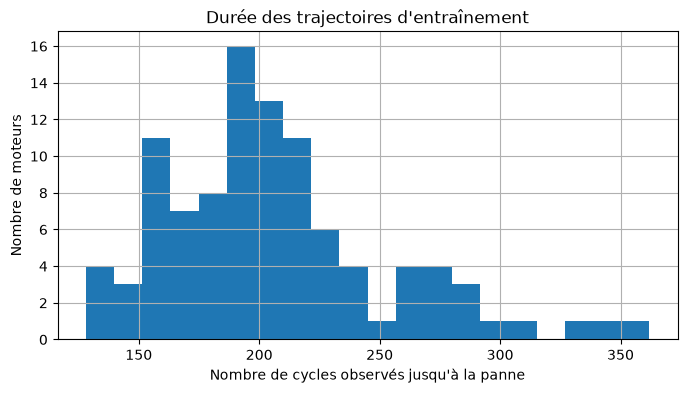

In [9]:
life = train.groupby("engine_id")["cycle"].max()
display(life.describe())

plt.figure(figsize=(8, 4))
life.hist(bins=20)
plt.title("Durée des trajectoires d'entraînement")
plt.xlabel("Nombre de cycles observés jusqu'à la panne")
plt.ylabel("Nombre de moteurs")
plt.show()


### Analyse du résultat

La durée médiane est de 199 cycles, mais elle s'étend de 128 à 362 cycles. Cette hétérogénéité interdit de confondre numéro de cycle et proximité de panne et renforce la nécessité d'un split par moteur.


## 5. Construction explicite de la vérité terrain

Dans le **train NASA**, chaque trajectoire se termine à la panne. Pour une ligne donnée :

`RUL = dernier_cycle_du_moteur - cycle_actuel`

Puis : `failure_within_30_cycles = 1` si `RUL <= 30`, sinon `0`.

`RUL` et la cible sont des **vérités terrain** : elles ne seront jamais utilisées comme variables prédictives.


In [10]:
FAILURE_WINDOW = 30

labelled = train.copy()
labelled["max_cycle"] = labelled.groupby("engine_id")["cycle"].transform("max")
labelled["RUL"] = labelled["max_cycle"] - labelled["cycle"]
labelled["failure_within_30_cycles"] = (
    labelled["RUL"] <= FAILURE_WINDOW
).astype("int8")

display(
    labelled[["engine_id", "cycle", "max_cycle", "RUL", "failure_within_30_cycles"]].head(12)
)


,engine_id,cycle,max_cycle,RUL,failure_within_30_cycles
0,1,1,192,191,0
1,1,2,192,190,0
2,1,3,192,189,0
3,1,4,192,188,0
4,1,5,192,187,0
5,1,6,192,186,0
6,1,7,192,185,0
7,1,8,192,184,0
8,1,9,192,183,0
9,1,10,192,182,0


### Analyse du résultat

Pour le moteur 1, le RUL décroît exactement d'une unité par cycle à partir de 191. La cible devient positive seulement dans les 30 derniers cycles : elle représente bien une alerte à horizon fixe, pas la panne au cycle courant.


## 6. Séparation des moteurs AVANT toute analyse supervisée

La séparation est faite par `engine_id`, pas ligne par ligne. Ainsi un même moteur ne peut pas être vu à la fois pendant l'apprentissage et l'évaluation.

- 70 % moteurs : TRAIN
- 15 % moteurs : CALIBRATION
- 15 % moteurs : VALIDATION
- `test_FD001` : holdout NASA externe, séparé de cette boucle de développement


In [11]:
RANDOM_STATE = 42
engines = np.array(sorted(labelled["engine_id"].unique()))
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(engines)

n_engines = len(engines)
n_train = round(n_engines * 0.70)
n_cal = round(n_engines * 0.15)

train_ids = set(engines[:n_train])
calibration_ids = set(engines[n_train:n_train + n_cal])
validation_ids = set(engines[n_train + n_cal:])

train_dev = labelled[labelled["engine_id"].isin(train_ids)].copy()
calibration_dev = labelled[labelled["engine_id"].isin(calibration_ids)].copy()
validation_dev = labelled[labelled["engine_id"].isin(validation_ids)].copy()

assert train_ids.isdisjoint(calibration_ids)
assert train_ids.isdisjoint(validation_ids)
assert calibration_ids.isdisjoint(validation_ids)

print("TRAIN       :", train_dev["engine_id"].nunique(), "moteurs /", len(train_dev), "lignes")
print("CALIBRATION :", calibration_dev["engine_id"].nunique(), "moteurs /", len(calibration_dev), "lignes")
print("VALIDATION  :", validation_dev["engine_id"].nunique(), "moteurs /", len(validation_dev), "lignes")


TRAIN       : 70 moteurs / 14407 lignes
CALIBRATION : 15 moteurs / 3160 lignes
VALIDATION  : 15 moteurs / 3064 lignes


### Analyse du résultat

Les 100 moteurs sont répartis en 70/15/15, soit 14 407 lignes d'entraînement, 3 160 de calibration et 3 064 de validation. La séparation par identifiant empêche qu'une trajectoire contribue à plusieurs partitions.


## 7. Analyse de la cible — TRAIN uniquement


,count,proportion
failure_within_30_cycles,,
0,12237,0.849379
1,2170,0.150621


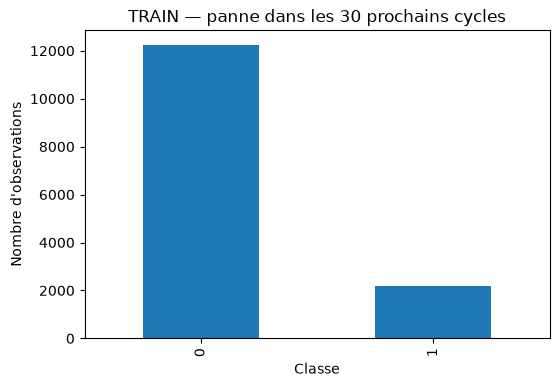

In [12]:
counts = train_dev["failure_within_30_cycles"].value_counts().sort_index()
proportions = (counts / counts.sum()).rename("proportion")

display(pd.concat([counts.rename("count"), proportions], axis=1))

plt.figure(figsize=(6, 4))
counts.plot(kind="bar")
plt.title("TRAIN — panne dans les 30 prochains cycles")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.show()


### Analyse du résultat

Seules 15,1 % des lignes TRAIN sont positives. L'accuracy brute serait donc trompeuse ; le rappel, la précision, la PR-AUC et un coût asymétrique sont plus pertinents pour comparer les modèles.


## 8. Variance et corrélations exploratoires — TRAIN uniquement


In [13]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

variance = train_dev[sensor_cols + ["setting_1", "setting_2", "setting_3"]].var().sort_values()
constant_or_quasi = variance[variance < 1e-12]
display(constant_or_quasi.to_frame("variance"))


,variance
sensor_1,0.000000e+00
setting_3,0.000000e+00
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,1.083411e-34
sensor_10,1.972289e-31
sensor_5,2.840096e-29


### Analyse du résultat

Sept variables ont une variance nulle ou numériquement négligeable. Elles doivent être retirées avant l'apprentissage pour réduire le bruit et éviter d'attribuer une importance artificielle à des constantes.


,abs_corr_RUL_train_only
sensor_11,0.680774
sensor_4,0.663944
sensor_12,0.654795
sensor_7,0.641963
sensor_15,0.630856
sensor_21,0.620808
sensor_20,0.615255
sensor_2,0.592344
sensor_17,0.591766
sensor_3,0.573830


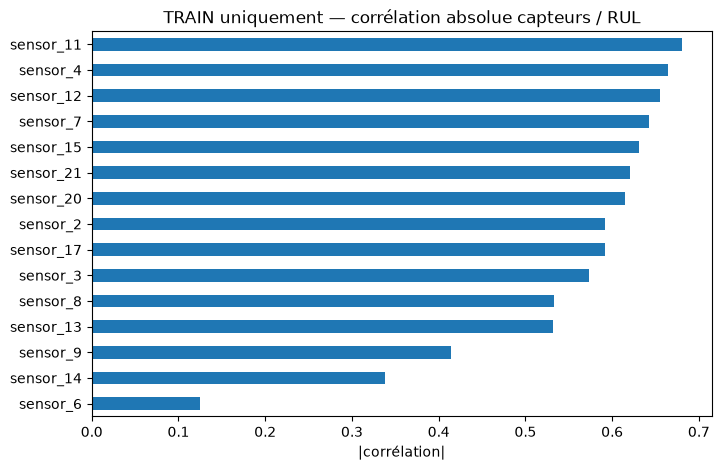

In [14]:
rul_corr = (
    train_dev[sensor_cols + ["RUL"]]
    .corr(numeric_only=True)["RUL"]
    .drop("RUL")
    .abs()
    .sort_values(ascending=False)
)

display(rul_corr.head(15).to_frame("abs_corr_RUL_train_only"))

plt.figure(figsize=(8, 5))
rul_corr.head(15).sort_values().plot(kind="barh")
plt.title("TRAIN uniquement — corrélation absolue capteurs / RUL")
plt.xlabel("|corrélation|")
plt.show()


### Analyse du résultat

Les capteurs 11 et 4 ont les associations linéaires absolues les plus fortes avec le RUL (0,681 et 0,664), suivis des capteurs 12, 7 et 15. Une faible corrélation ne signifie pas inutilité : les tendances locales et relations non linéaires seront captées par les features temporelles et les modèles.


## 9. Trajectoires de quelques capteurs — TRAIN uniquement


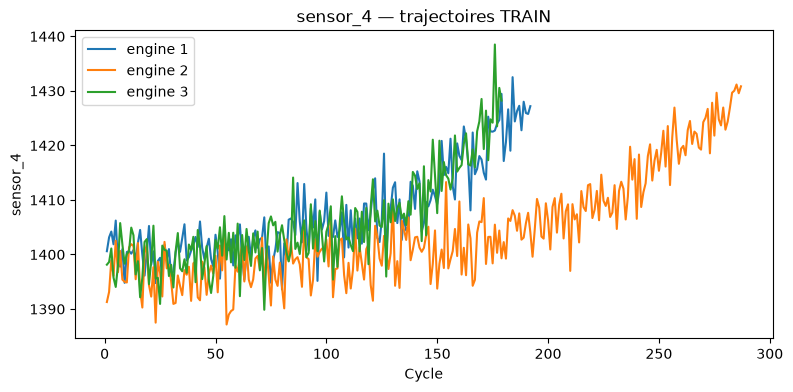

In [15]:
sample_engines = sorted(list(train_ids))[:3]

sensor = "sensor_4"
plt.figure(figsize=(9, 4))
for engine_id in sample_engines:
    trajectory = train_dev[train_dev["engine_id"] == engine_id]
    plt.plot(trajectory["cycle"], trajectory[sensor], label=f"engine {engine_id}")
plt.title(f"{sensor} — trajectoires TRAIN")
plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.legend()
plt.show()


### Analyse du résultat

Pour les moteurs 1 à 3, la moyenne des 20 derniers cycles dépasse celle des 20 premiers d'environ 23 à 28 unités. La hausse commune malgré le bruit fait du capteur 4 un indicateur de dégradation particulièrement crédible.


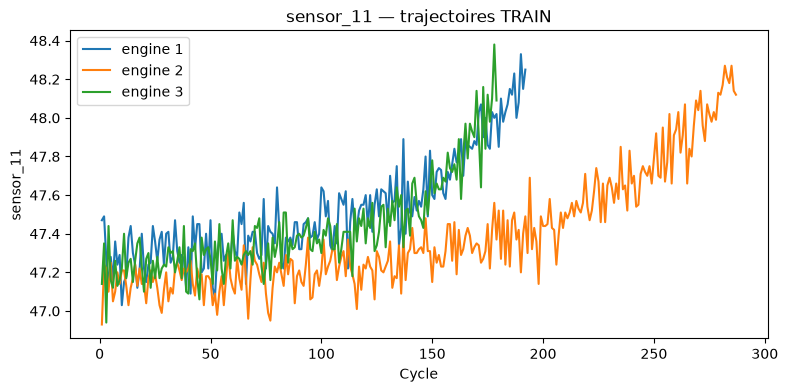

In [16]:
sensor = "sensor_11"
plt.figure(figsize=(9, 4))
for engine_id in sample_engines:
    trajectory = train_dev[train_dev["engine_id"] == engine_id]
    plt.plot(trajectory["cycle"], trajectory[sensor], label=f"engine {engine_id}")
plt.title(f"{sensor} — trajectoires TRAIN")
plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.legend()
plt.show()


### Analyse du résultat

Le capteur 11 augmente également entre le début et la fin des trois trajectoires échantillonnées, d'environ 0,71 à 0,94 unité. Ce comportement cohérent avec sa forte corrélation au RUL justifie ses nombreuses transformations temporelles.


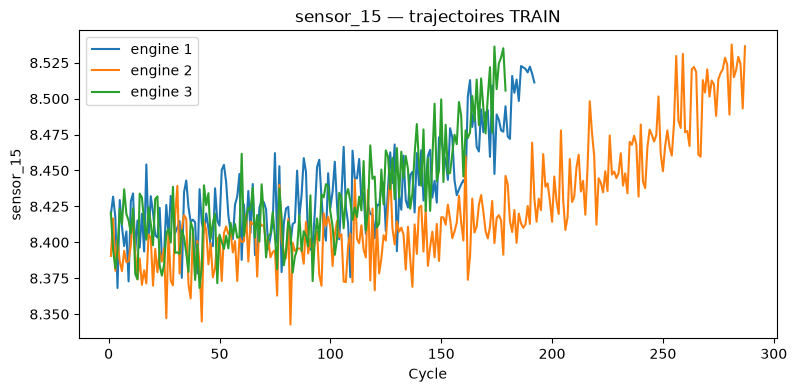

In [17]:
sensor = "sensor_15"
plt.figure(figsize=(9, 4))
for engine_id in sample_engines:
    trajectory = train_dev[train_dev["engine_id"] == engine_id]
    plt.plot(trajectory["cycle"], trajectory[sensor], label=f"engine {engine_id}")
plt.title(f"{sensor} — trajectoires TRAIN")
plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.legend()
plt.show()


### Analyse du résultat

Le capteur 15 progresse plus faiblement, d'environ 0,09 à 0,13 entre les 20 premiers et les 20 derniers cycles. Le signal existe, mais son amplitude réduite rend les moyennes glissantes utiles pour atténuer le bruit cycle par cycle.


## 10. Vérification de l'industrialisation

Le notebook a montré le chargement et les contrôles **manuellement**. Le projet contient aussi des fonctions réutilisables dans `src/data/` pour éviter de recopier cette logique dans l'API, les tests et le retraining.

Cette cellule ne change aucune décision Data Science ; elle vérifie seulement que le code industrialisé charge exactement les mêmes données.


In [18]:
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.load import load_train_fd001

train_src = load_train_fd001()
pd.testing.assert_frame_equal(train.reset_index(drop=True), train_src.reset_index(drop=True))

print("OK : chargement manuel TRAIN et chargement industrialisé identiques.")
print("Le holdout RUL reste fermé jusqu'au notebook 05 / src.models.evaluate.")


OK : chargement manuel TRAIN et chargement industrialisé identiques.
Le holdout RUL reste fermé jusqu'au notebook 05 / src.models.evaluate.


### Analyse du résultat

L'égalité exacte confirme que le chargeur de production reproduit le chargement manuel. Le notebook reste donc pédagogique sans créer une seconde logique de préparation divergente.


## Conclusion EDA

- Le chargement des trois fichiers FD001 est explicitement visible.
- Les contrôles de qualité sont compréhensibles et reproductibles.
- Le holdout NASA n'est pas utilisé pour prendre des décisions de développement.
- Les analyses dépendant de la cible sont limitées à TRAIN.
- Le projet peut maintenant passer au feature engineering causal et à la sélection de variables.
